# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q1 Answers:**

1. A model is linear in its parameters/coefficients. The prediction is a linear combination of the coefficients, even if the features themselves are nonlinear transformations of the input (like x^2, log(x), etc.).

2. A dummy variable coefficient represents the difference in the outcome between that category and the reference category (the one dropped or absorbed into the intercept). The intercept represents the expected value for the reference category.

3. Linear regression can technically be used for classification by treating predicted values as probabilities, but it has problems: predictions can fall outside [0,1], it assumes equal spacing between classes, and it doesn't model the probability distribution properly. Logistic regression is better suited for classification.

4. Signs of overfitting include: high training accuracy but poor test accuracy, very large coefficient magnitudes, model performs well on training data but poorly on new data, and high variance in predictions across different train/test splits.

5. Multicollinearity occurs when predictors are highly correlated, making it hard to isolate individual effects. In two stage least squares: first, you regress the problematic predictor on other variables to get predicted values second, you use those predicted values (which are orthogonal to the error term) in the main regression. This helps identify causal effects when there's endogeneity.

6. You can incorporate nonlinear relationships by adding polynomial terms (x, x^2, x^3), using logarithmic or exponential transformations, creating interaction terms (x_1 × x_2), using splines or basis functions, or binning continuous variables into categories.

7. The slope coefficient represents the expected change in the outcome variable for a one unit increase in the predictor, holding all other variables constant. It quantifies the marginal effect of that predictor.

8. Train/test split divides data once into two sets you train on one and test on the other. K-fold CV divides data into k parts, trains on k 1 parts and tests on the remaining part, rotating through all k combinations. CV gives more reliable performance estimates by using all data for both training and testing, but requires k times more computation.

9. Common choices for k are 5 or 10. Larger k gives less biased estimates but higher variance and more computation. Smaller k is faster but more biased. The choice balances computational cost with the need for reliable estimates. For small datasets, leave-one-out CV (k=n) is sometimes used.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [1]:
# Setup: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

In [2]:
# Q2.1: Load data and compute averages by neighbourhood
airbnb = pd.read_csv('./data/Q1_clean.csv')

airbnb = airbnb.rename(columns={'Neighbourhood ': 'Neighbourhood'})

print("Data shape:", airbnb.shape)
print("\nFirst few rows:")
display(airbnb.head())

#averages by neighbourhood
neighbourhood_stats = airbnb.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().sort_values('Price', ascending=False)
print("\nAverage Price and Review Scores by Neighbourhood:")
display(neighbourhood_stats)
print(f"\nMost expensive borough: {neighbourhood_stats.index[0]} with average price ${neighbourhood_stats.iloc[0]['Price']:.2f}")

Data shape: (22153, 5)

First few rows:


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt



Average Price and Review Scores by Neighbourhood:


,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.6643,91.8015
Staten Island,146.1667,90.8438
Brooklyn,127.7474,92.3635
Queens,96.8572,91.5491
Bronx,75.2765,91.6544



Most expensive borough: Manhattan with average price $183.66


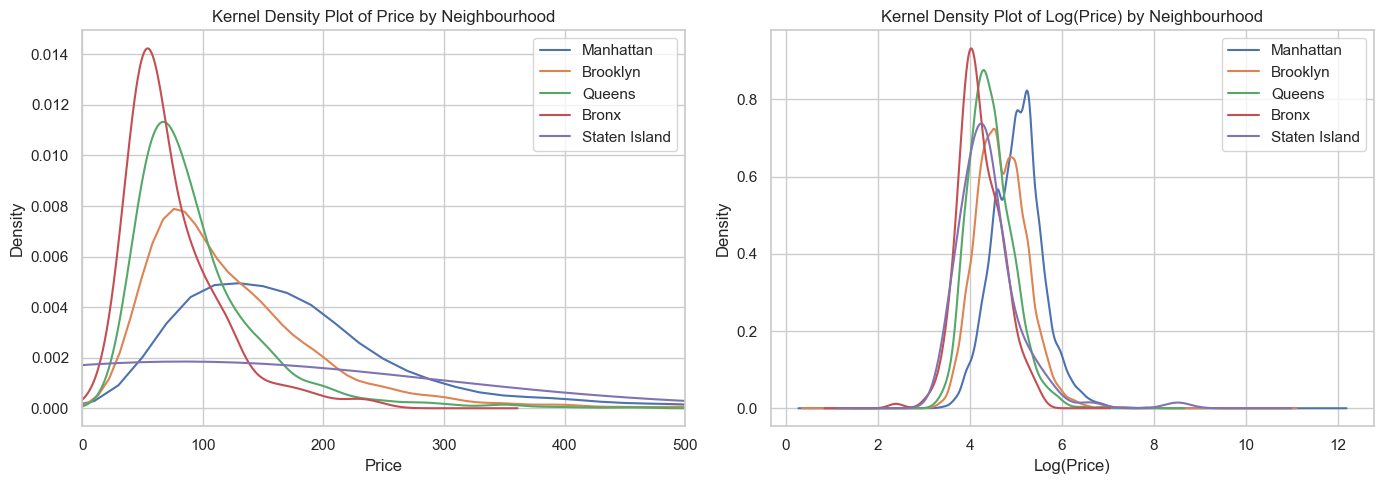

In [3]:
# Q2.1:kernel density plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price KDE
for neighbourhood in airbnb['Neighbourhood'].unique():
    subset = airbnb[airbnb['Neighbourhood'] == neighbourhood]['Price']
    subset.plot.kde(ax=axes[0], label=neighbourhood)
axes[0].set_xlabel('Price')
axes[0].set_title('Kernel Density Plot of Price by Neighbourhood')
axes[0].legend()
axes[0].set_xlim(0, 500)  # Limit x-axis for better visualization

# Log Price KDE
for neighbourhood in airbnb['Neighbourhood'].unique():
    subset = np.log(airbnb[airbnb['Neighbourhood'] == neighbourhood]['Price'] + 1)  # +1 to avoid log(0)
    subset.plot.kde(ax=axes[1], label=neighbourhood)
axes[1].set_xlabel('Log(Price)')
axes[1].set_title('Kernel Density Plot of Log(Price) by Neighbourhood')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Q2.2: Regress price on neighbourhood (with dummy variables)
#dummy variables, dropping the first category to avoid dummy variable trap
X_neighbourhood = pd.get_dummies(airbnb['Neighbourhood'], drop_first=True, dtype=float)
y = airbnb['Price']

model_q2_2 = LinearRegression()
model_q2_2.fit(X_neighbourhood, y)

#coefficient dataframe
coef_df = pd.DataFrame({
    'Neighbourhood': X_neighbourhood.columns,
    'Coefficient': model_q2_2.coef_
})

print("Q2.2: Regression of Price on Neighbourhood")
print(f"\nIntercept (reference category): ${model_q2_2.intercept_:.2f}")
print("\nCoefficients (difference from reference):")
display(coef_df)

#reference category is the first one alphabetically (dropped)
reference_cat = sorted(airbnb['Neighbourhood'].unique())[0]
print(f"\nReference category: {reference_cat}")
print(f"\nInterpretation: The intercept ({model_q2_2.intercept_:.2f}) is the average price in {reference_cat}.")
print("Each coefficient shows how much more (or less) expensive that neighbourhood is compared to the reference.")

Q2.2: Regression of Price on Neighbourhood

Intercept (reference category): $75.28

Coefficients (difference from reference):


,Neighbourhood,Coefficient
0,Brooklyn,52.4709
1,Manhattan,108.3878
2,Queens,21.5807
3,Staten Island,70.8902



Reference category: Bronx

Interpretation: The intercept (75.28) is the average price in Bronx.
Each coefficient shows how much more (or less) expensive that neighbourhood is compared to the reference.


In [5]:
# Q2.3: Regress price on Review Scores Rating
X_rating = airbnb[['Review Scores Rating']].dropna()
y_rating = airbnb.loc[X_rating.index, 'Price']

model_q2_3 = LinearRegression()
model_q2_3.fit(X_rating, y_rating)

print("Q2.3: Regression of Price on Review Scores Rating")
print(f"\nIntercept: ${model_q2_3.intercept_:.2f}")
print(f"Slope coefficient: ${model_q2_3.coef_[0]:.2f}")
print(f"R²: {model_q2_3.score(X_rating, y_rating):.4f}")

print(f"\nInterpretation: For each 1-point increase in Review Scores Rating, ")
print(f"the price is expected to increase by ${model_q2_3.coef_[0]:.2f}, on average.")

Q2.3: Regression of Price on Review Scores Rating

Intercept: $60.88
Slope coefficient: $1.02
R²: 0.0037

Interpretation: For each 1-point increase in Review Scores Rating, 
the price is expected to increase by $1.02, on average.


In [6]:
# Q2.4: Regress price on both Neighbourhood and Review Scores Rating
#prepare data (drop rows with missing ratings)
airbnb_clean = airbnb.dropna(subset=['Review Scores Rating'])
X_both = pd.get_dummies(airbnb_clean['Neighbourhood'], drop_first=True, dtype=float)
X_both['Review Scores Rating'] = airbnb_clean['Review Scores Rating'].values
y_both = airbnb_clean['Price']

model_q2_4 = LinearRegression()
model_q2_4.fit(X_both, y_both)

print("Q2.4: Regression of Price on Neighbourhood AND Review Scores Rating")
print(f"\nIntercept: ${model_q2_4.intercept_:.2f}")
print(f"\nReview Scores Rating coefficient: ${model_q2_4.coef_[-1]:.2f}")
print(f"  (Previous model without neighbourhood: ${model_q2_3.coef_[0]:.2f})")
print(f"\nChange in Review Scores Rating coefficient: ${model_q2_4.coef_[-1] - model_q2_3.coef_[0]:.2f}")

#neighbourhood coefficients
coef_df_q4 = pd.DataFrame({
    'Variable': list(X_both.columns[:-1]) + ['Review Scores Rating'],
    'Coefficient': model_q2_4.coef_
})
print("\nAll coefficients:")
display(coef_df_q4)

print("\nThe Review Scores Rating coefficient changed because we're now controlling for neighbourhood.")
print("The neighbourhood coefficients now represent differences in price after accounting for review scores.")

Q2.4: Regression of Price on Neighbourhood AND Review Scores Rating

Intercept: $-23.81

Review Scores Rating coefficient: $1.08
  (Previous model without neighbourhood: $1.02)

Change in Review Scores Rating coefficient: $0.06

All coefficients:


,Variable,Coefficient
0,Brooklyn,51.7042
1,Manhattan,108.2287
2,Queens,21.6946
3,Staten Island,71.7666
4,Review Scores Rating,1.0811



The Review Scores Rating coefficient changed because we're now controlling for neighbourhood.
The neighbourhood coefficients now represent differences in price after accounting for review scores.


In [7]:
# Q2.5: Separate slope for each neighbourhood (interaction model)
#Neighbourhood * Review Scores Rating
X_interact = pd.get_dummies(airbnb_clean['Neighbourhood'], drop_first=False, dtype=float)  # Keep all dummies

#interaction terms for each neighbourhood
for col in X_interact.columns:
    X_interact[f'{col}_x_Rating'] = X_interact[col] * airbnb_clean['Review Scores Rating'].values

# Remove the neighbourhood main effects (only want intercept + interactions)
X_interact_only = X_interact[[col for col in X_interact.columns if '_x_Rating' in col]]

model_q2_5 = LinearRegression()
model_q2_5.fit(X_interact_only, y_both)

print("Q2.5: Separate slope for Review Scores Rating in each neighbourhood")
print(f"\nIntercept: ${model_q2_5.intercept_:.2f}")

#slopes by neighbourhood
slopes_df = pd.DataFrame({
    'Neighbourhood': [col.replace('_x_Rating', '') for col in X_interact_only.columns],
    'Slope': model_q2_5.coef_
}).sort_values('Slope', ascending=False)

print("\nSlope coefficients for Review Scores Rating by Neighbourhood:")
display(slopes_df)

print(f"\nRange of slopes: ${slopes_df['Slope'].min():.2f} to ${slopes_df['Slope'].max():.2f}")
print(f"Standard deviation: ${slopes_df['Slope'].std():.2f}")
print("\nThe slopes vary considerably across neighbourhoods, suggesting that the relationship")
print("between review scores and price differs by location.")

Q2.5: Separate slope for Review Scores Rating in each neighbourhood

Intercept: $55.12

Slope coefficients for Review Scores Rating by Neighbourhood:


,Neighbourhood,Slope
2,Manhattan,1.3994
1,Brooklyn,0.7909
4,Staten Island,0.6824
3,Queens,0.4565
0,Bronx,0.2227



Range of slopes: $0.22 to $1.40
Standard deviation: $0.44

The slopes vary considerably across neighbourhoods, suggesting that the relationship
between review scores and price differs by location.


In [8]:
# Q2.6: Cross-validation comparison of models from parts 2, 4, and 5
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Model from part 2: Neighbourhood only
X_model2 = pd.get_dummies(airbnb_clean['Neighbourhood'], drop_first=True, dtype=float)
scores_model2 = -cross_val_score(LinearRegression(), X_model2, y_both, 
                                  cv=kf, scoring='neg_mean_squared_error')

# Model from part 4: Neighbourhood + Review Scores Rating
scores_model4 = -cross_val_score(LinearRegression(), X_both, y_both, 
                                  cv=kf, scoring='neg_mean_squared_error')

# Model from part 5: Separate slopes
scores_model5 = -cross_val_score(LinearRegression(), X_interact_only, y_both, 
                                  cv=kf, scoring='neg_mean_squared_error')

print("Q2.6: 10-Fold Cross-Validation Results (MSE)")
print("="*60)

results_df = pd.DataFrame({
    'Model': ['Part 2: Neighbourhood only', 
              'Part 4: Neighbourhood + Rating',
              'Part 5: Separate slopes by Neighbourhood'],
    'Mean MSE': [scores_model2.mean(), scores_model4.mean(), scores_model5.mean()],
    'Std MSE': [scores_model2.std(), scores_model4.std(), scores_model5.std()],
    'RMSE': [np.sqrt(scores_model2.mean()), np.sqrt(scores_model4.mean()), np.sqrt(scores_model5.mean())]
})

display(results_df)

print(f"\nBest model: {results_df.loc[results_df['Mean MSE'].idxmin(), 'Model']}")
print("\nAdding Review Scores Rating improves prediction, and allowing separate slopes")
print("per neighbourhood provides the best fit.")

Q2.6: 10-Fold Cross-Validation Results (MSE)


,Model,Mean MSE,Std MSE,RMSE
0,Part 2: Neighbourhood only,21155.0081,14936.5115,145.4476
1,Part 4: Neighbourhood + Rating,21070.8100,14914.6048,145.1579
2,Part 5: Separate slopes by Neighbourhood,21048.9283,14913.3115,145.0825



Best model: Part 5: Separate slopes by Neighbourhood

Adding Review Scores Rating improves prediction, and allowing separate slopes
per neighbourhood provides the best fit.


Data shape: (976, 12)

First few rows:


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000



Price summary statistics:


count    9.7600e+02
mean     7.4102e+05
std      3.6732e+05
min      1.8800e+05
25%      4.7575e+05
50%      6.6650e+05
75%      8.8300e+05
max      2.9410e+06
Name: Price, dtype: float64

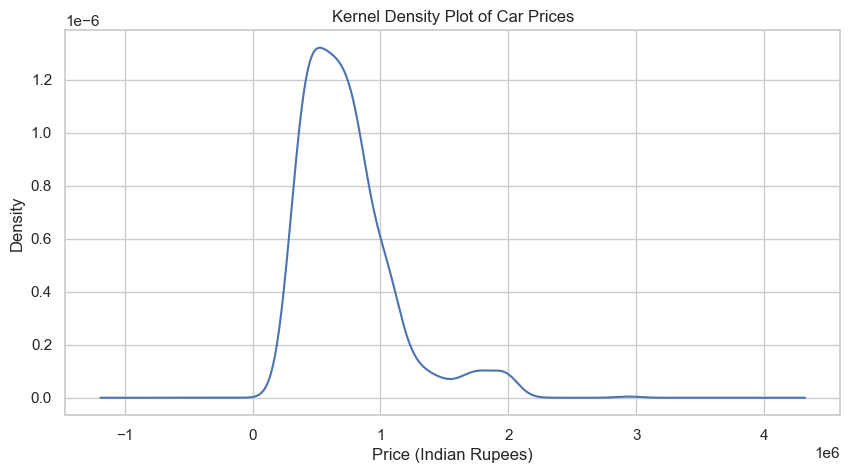


Price statistics by Body Type:


,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.0510e+05,72849.7802,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.3398e+05,173086.7298,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.2642e+05,184093.4885,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.0978e+05,286736.7701,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.1765e+06,417479.0282,559000.0,860000.0,1065000.0,1491250.0,2100000.0


In [9]:
# Q3.1: summarize car data
cars = pd.read_csv('./data/cars_hw.csv')

print("Data shape:", cars.shape)
print("\nFirst few rows:")
display(cars.head())

print("\nPrice summary statistics:")
display(cars['Price'].describe())

#KDE plot of price
plt.figure(figsize=(10, 5))
cars['Price'].plot.kde()
plt.xlabel('Price (Indian Rupees)')
plt.title('Kernel Density Plot of Car Prices')
plt.show()

print("\nPrice statistics by Body Type:")
display(cars.groupby('Body_Type')['Price'].describe())

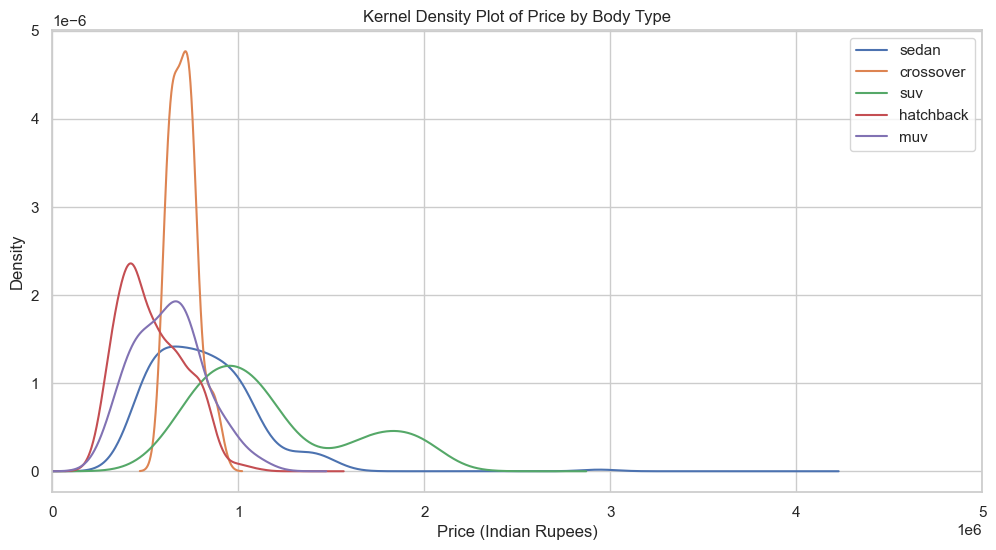


Mean and Standard Deviation by Body Type:


,mean,std
Body_Type,,
suv,1.1765e+06,417479.0282
sedan,8.0978e+05,286736.7701
crossover,7.0510e+05,72849.7802
muv,6.2642e+05,184093.4885
hatchback,5.3398e+05,173086.7298



Most expensive: suv
Highest variance: suv


In [10]:
# Q3.1: KDE plot by Body_Type
plt.figure(figsize=(12, 6))
for body_type in cars['Body_Type'].unique():
    subset = cars[cars['Body_Type'] == body_type]['Price']
    subset.plot.kde(label=body_type)

plt.xlabel('Price (Indian Rupees)')
plt.title('Kernel Density Plot of Price by Body Type')
plt.legend()
plt.xlim(0, 5000000)  # Limit for better visualization
plt.show()

#most expensive and highest variance
price_stats = cars.groupby('Body_Type')['Price'].agg(['mean', 'std']).sort_values('mean', ascending=False)
print("\nMean and Standard Deviation by Body Type:")
display(price_stats)
print(f"\nMost expensive: {price_stats.index[0]}")
print(f"Highest variance: {price_stats.sort_values('std', ascending=False).index[0]}")

In [11]:
# Q3.2: Regress Price on Seating_Capacity (continuous and categorical)
X_seats_cont = cars[['Seating_Capacity']].dropna()
y_cars = cars.loc[X_seats_cont.index, 'Price']

model_seats_cont = LinearRegression()
model_seats_cont.fit(X_seats_cont, y_cars)

print("Q3.2: Regression of Price on Seating_Capacity (continuous)")
print(f"\nIntercept: ₹{model_seats_cont.intercept_:,.2f}")
print(f"Slope coefficient: ₹{model_seats_cont.coef_[0]:,.2f}")
print(f"\nInterpretation: For each additional seat, price increases by ₹{model_seats_cont.coef_[0]:,.2f} on average.")

# Treat as categorical
X_seats_cat = pd.get_dummies(cars['Seating_Capacity'], drop_first=True, dtype=float, prefix='Seats')
model_seats_cat = LinearRegression()
model_seats_cat.fit(X_seats_cat, y_cars)

print("\nRegression with Seating_Capacity as categorical:")
print(f"Intercept: ₹{model_seats_cat.intercept_:,.2f}")
coef_seats = pd.DataFrame({'Seating_Capacity': X_seats_cat.columns, 'Coefficient': model_seats_cat.coef_})
display(coef_seats)
print("\nThe relationship is NOT perfectly linear - some seat counts have larger price differences.")

Q3.2: Regression of Price on Seating_Capacity (continuous)

Intercept: ₹439,032.01
Slope coefficient: ₹59,268.00

Interpretation: For each additional seat, price increases by ₹59,268.00 on average.

Regression with Seating_Capacity as categorical:
Intercept: ₹188,000.00


,Seating_Capacity,Coefficient
0,Seats_5,5.4648e+05
1,Seats_6,1.4560e+06
2,Seats_7,7.3595e+05
3,Seats_8,2.7180e+05



The relationship is NOT perfectly linear - some seat counts have larger price differences.


In [12]:
# Q3.3: Create Age variable and find optimal polynomial degree
current_year = 2024
cars['Age'] = current_year - cars['Make_Year']
cars_age = cars.dropna(subset=['Age', 'Price'])

# Test polynomial degrees 1-5 with cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
degrees = range(1, 6)
cv_scores = []

for degree in degrees:
    X_poly = np.column_stack([cars_age['Age']**i for i in range(1, degree+1)])
    y_age = cars_age['Price']
    scores = -cross_val_score(LinearRegression(), X_poly, y_age, cv=kf, scoring='neg_mean_squared_error')
    cv_scores.append(scores.mean())

cv_results = pd.DataFrame({'Degree': degrees, 'Mean MSE': cv_scores, 'RMSE': np.sqrt(cv_scores)})
print("Q3.3: Cross-validation results for polynomial regression")
display(cv_results)
optimal_degree = int(cv_results.loc[cv_results['Mean MSE'].idxmin(), 'Degree'])
print(f"\nOptimal polynomial degree: {optimal_degree}")

Q3.3: Cross-validation results for polynomial regression


,Degree,Mean MSE,RMSE
0,1,9.7377e+10,312053.2776
1,2,9.7396e+10,312082.8511
2,3,9.6743e+10,311035.6970
3,4,9.6225e+10,310201.6090
4,5,9.5265e+10,308650.3451



Optimal polynomial degree: 5


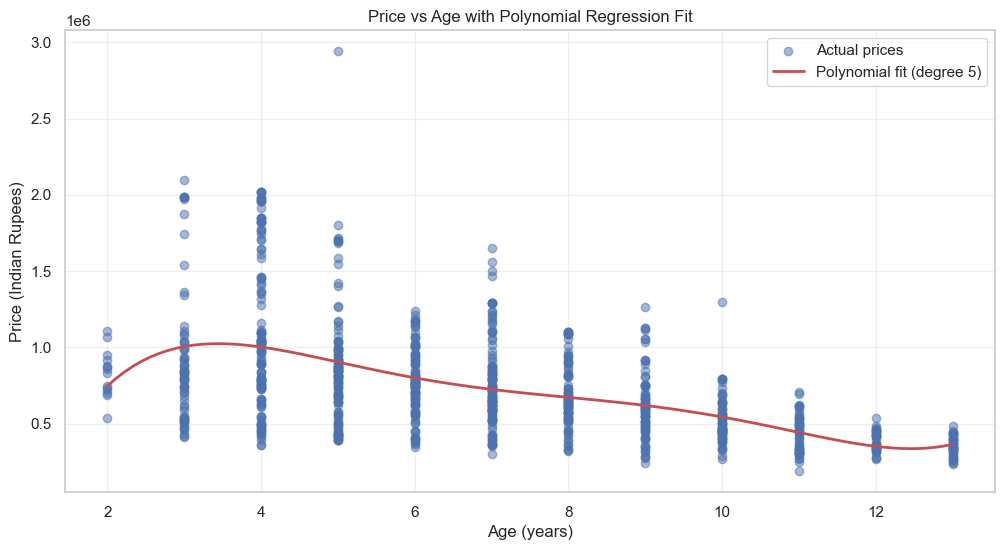

The polynomial model captures the depreciation trend, though there's substantial variation.


In [13]:
# Q3.4:Price vs Age with model predictions
X_poly_opt = np.column_stack([cars_age['Age']**i for i in range(1, optimal_degree+1)])
model_age = LinearRegression()
model_age.fit(X_poly_opt, cars_age['Price'])

age_range = np.linspace(cars_age['Age'].min(), cars_age['Age'].max(), 100)
X_pred = np.column_stack([age_range**i for i in range(1, optimal_degree+1)])
y_pred = model_age.predict(X_pred)

plt.figure(figsize=(12, 6))
plt.scatter(cars_age['Age'], cars_age['Price'], alpha=0.5, label='Actual prices')
plt.plot(age_range, y_pred, 'r-', linewidth=2, label=f'Polynomial fit (degree {optimal_degree})')
plt.xlabel('Age (years)')
plt.ylabel('Price (Indian Rupees)')
plt.title('Price vs Age with Polynomial Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The polynomial model captures the depreciation trend, though there's substantial variation.")

In [14]:
# Q4.1: Load data and compute ATE
heart = pd.read_csv('./data/heart_hw.csv')
print("Data shape:", heart.shape)
display(heart.head())

survival_by_group = heart.groupby('transplant')['y'].mean()
control_survival = survival_by_group['control']
treatment_survival = survival_by_group['treatment']
ate = treatment_survival - control_survival

print(f"\nQ4.1 Results:")
print(f"(a) Control survival: {control_survival:.4f}")
print(f"(b) Treatment survival: {treatment_survival:.4f}")
print(f"\nATE: {ate:.4f} ({ate:.1%} {'increase' if ate > 0 else 'decrease'} in survival)")

Data shape: (103, 4)


,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0



Q4.1 Results:
(a) Control survival: 0.1176
(b) Treatment survival: 0.3478

ATE: 0.2302 (23.0% increase in survival)


In [15]:
# Q4.2: Regress y on transplant
X_transplant = pd.get_dummies(heart['transplant'], drop_first=True, dtype=float)
y_heart = heart['y']
model_q4_2 = LinearRegression()
model_q4_2.fit(X_transplant, y_heart)

print("Q4.2: Regression of survival on transplant")
print(f"Intercept: {model_q4_2.intercept_:.4f} (= control survival {control_survival:.4f})")
print(f"Coefficient: {model_q4_2.coef_[0]:.4f} (= ATE {ate:.4f})")
print("\nThe regression recovers the same values from part 1.")

Q4.2: Regression of survival on transplant
Intercept: 0.1176 (= control survival 0.1176)
Coefficient: 0.2302 (= ATE 0.2302)

The regression recovers the same values from part 1.


Q4.3: Regression with age control
Intercept: 0.7020
Transplant coef: 0.2647 (was 0.2302)
Age coef: -0.0136


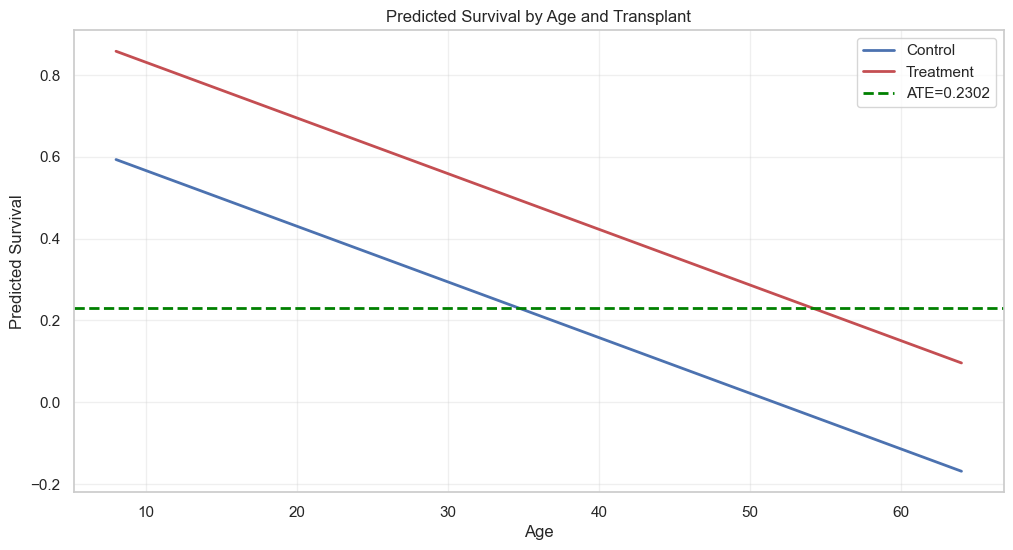

In [16]:
# Q4.3: Regress y on transplant and age
X_both_q4 = pd.get_dummies(heart['transplant'], drop_first=True, dtype=float)
X_both_q4['age'] = heart['age'].values
model_q4_3 = LinearRegression()
model_q4_3.fit(X_both_q4, y_heart)

print("Q4.3: Regression with age control")
print(f"Intercept: {model_q4_3.intercept_:.4f}")
print(f"Transplant coef: {model_q4_3.coef_[0]:.4f} (was {model_q4_2.coef_[0]:.4f})")
print(f"Age coef: {model_q4_3.coef_[1]:.4f}")

#plot
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)
y_control = model_q4_3.predict(pd.DataFrame({'treatment': 0, 'age': age_range}))
y_treatment = model_q4_3.predict(pd.DataFrame({'treatment': 1, 'age': age_range}))

plt.figure(figsize=(12, 6))
plt.plot(age_range, y_control, 'b-', linewidth=2, label='Control')
plt.plot(age_range, y_treatment, 'r-', linewidth=2, label='Treatment')
plt.axhline(y=ate, color='green', linestyle='--', linewidth=2, label=f'ATE={ate:.4f}')
plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.title('Predicted Survival by Age and Transplant')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Q4.4: Regression with interaction
Intercept: 0.3549
Transplant: 0.9078
Age: -0.0055
Interaction: -0.0146


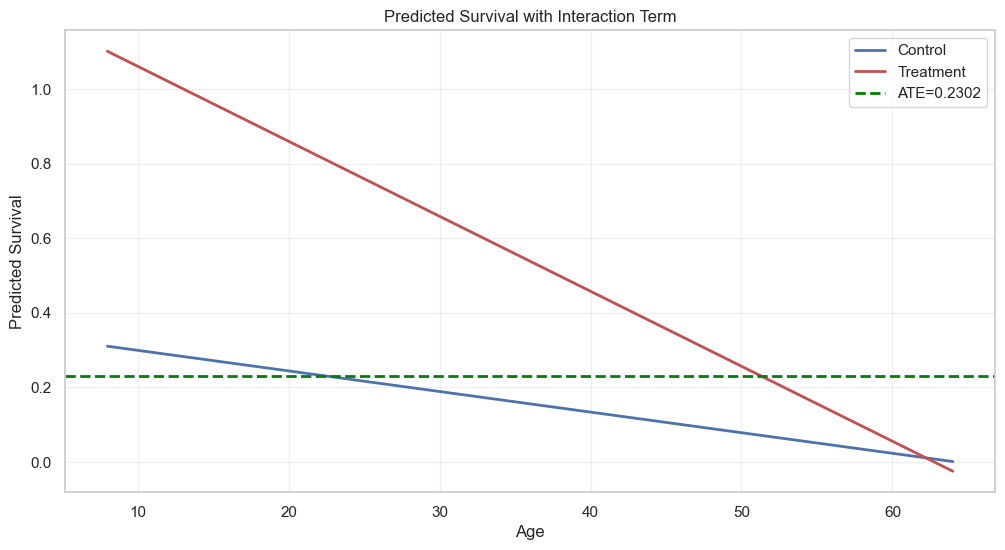


Lines are no longer parallel - treatment effect varies with age.


In [17]:
# Q4.4:interaction term
X_interact_q4 = pd.get_dummies(heart['transplant'], drop_first=True, dtype=float)
X_interact_q4['age'] = heart['age'].values
X_interact_q4['transplant_x_age'] = X_interact_q4['treatment'] * X_interact_q4['age']
model_q4_4 = LinearRegression()
model_q4_4.fit(X_interact_q4, y_heart)

print("Q4.4: Regression with interaction")
print(f"Intercept: {model_q4_4.intercept_:.4f}")
print(f"Transplant: {model_q4_4.coef_[0]:.4f}")
print(f"Age: {model_q4_4.coef_[1]:.4f}")
print(f"Interaction: {model_q4_4.coef_[2]:.4f}")

#plot with interaction
y_control_int = model_q4_4.predict(pd.DataFrame({'treatment': 0, 'age': age_range, 'transplant_x_age': 0}))
y_treatment_int = model_q4_4.predict(pd.DataFrame({'treatment': 1, 'age': age_range, 'transplant_x_age': age_range}))

plt.figure(figsize=(12, 6))
plt.plot(age_range, y_control_int, 'b-', linewidth=2, label='Control')
plt.plot(age_range, y_treatment_int, 'r-', linewidth=2, label='Treatment')
plt.axhline(y=ate, color='green', linestyle='--', linewidth=2, label=f'ATE={ate:.4f}')
plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.title('Predicted Survival with Interaction Term')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("\nLines are no longer parallel - treatment effect varies with age.")

In [18]:
# Q4.5: Cross-validation comparison
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores_m1 = -cross_val_score(LinearRegression(), X_transplant, y_heart, cv=kf, scoring='neg_mean_squared_error')
scores_m2 = -cross_val_score(LinearRegression(), X_both_q4, y_heart, cv=kf, scoring='neg_mean_squared_error')
scores_m3 = -cross_val_score(LinearRegression(), X_interact_q4, y_heart, cv=kf, scoring='neg_mean_squared_error')

cv_results_q4 = pd.DataFrame({
    'Model': ['Transplant only', 'Transplant + Age', 'With Interaction'],
    'Mean MSE': [scores_m1.mean(), scores_m2.mean(), scores_m3.mean()],
    'RMSE': [np.sqrt(scores_m1.mean()), np.sqrt(scores_m2.mean()), np.sqrt(scores_m3.mean())]
})
print("Q4.5: Cross-Validation Results")
display(cv_results_q4)
print(f"\nBest model: {cv_results_q4.loc[cv_results_q4['Mean MSE'].idxmin(), 'Model']}")

Q4.5: Cross-Validation Results


,Model,Mean MSE,RMSE
0,Transplant only,0.1931,0.4394
1,Transplant + Age,0.1773,0.4210
2,With Interaction,0.1751,0.4185



Best model: With Interaction


**Q4.6: Concerns about deployment for transplant prioritization**

1. Causality: Model shows associations, not causal effects. Selection bias likely present.
2. Limited features: Only age and transplant status - missing disease severity, comorbidities, etc.
3. Linear probability issues: Predictions can fall outside [0,1].
4. Fairness: Age-based predictions could discriminate against older patients.
5. Self-fulfilling prophecy: Denying transplants prevents observing outcomes.
6. Small sample: Only 103 observations may not generalize.
7. Missing counterfactuals: Can't observe alternative outcomes.
